In [67]:
import pandas as pd
import numpy as np
df=pd.read_csv("05_sleep_hours_vs_test_score.csv")

In [69]:
df.loc[0,'sleep_hours']=np.nan

In [70]:
print(df.iloc[0,0])

nan


In [95]:
#Type conversion
df=df.apply(pd.to_numeric,errors='coerce')
s=df.isnull().sum()
print(s)
df=df.dropna()
print(df.info())
print(df.shape)

sleep_hours               0
attendance_pct            0
previous_score            0
parental_support_score    0
test_score                0
dtype: int64
<class 'pandas.DataFrame'>
Index: 239 entries, 1 to 309
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sleep_hours             239 non-null    float64
 1   attendance_pct          239 non-null    float64
 2   previous_score          239 non-null    float64
 3   parental_support_score  239 non-null    float64
 4   test_score              239 non-null    float64
dtypes: float64(5)
memory usage: 11.2 KB
None
(239, 5)


In [72]:
#print(df['parental_support_score'].values)
print('>--------Column Names---------<\n',df.columns)

>--------Column Names---------<
 Index(['sleep_hours', 'attendance_pct', 'previous_score',
       'parental_support_score', 'test_score'],
      dtype='str')


In [73]:
# Range correction
df=df[df['sleep_hours'].between(0,14)]
df=df[df['attendance_pct'].between(0,100)]
df=df[df['previous_score'].between(0,100)]
df=df[df['test_score'].between(0,100)]
df=df[df['parental_support_score'].between(0,10)]

In [97]:
print("----------Stastical information------------")
print(df.describe())
print(df.shape)

----------Stastical information------------
       sleep_hours  attendance_pct  previous_score  parental_support_score  \
count   239.000000      239.000000      239.000000              239.000000   
mean      6.702092       74.856904       64.609121                5.663849   
std       2.091127       15.684829       21.138510                2.503288   
min       0.000000        0.000000       30.500000                1.020000   
25%       4.950000       62.735000       46.215000                3.505000   
50%       6.800000       72.980000       63.910000                5.650000   
75%       8.600000       89.275000       84.505000                7.840000   
max      10.000000       99.760000       99.880000                9.940000   

       test_score  
count  239.000000  
mean    70.497908  
std     13.902081  
min     38.000000  
25%     58.500000  
50%     70.000000  
75%     82.000000  
max     99.000000  
(239, 5)


In [75]:
print("Number of duplicates",df.duplicated().sum())
df=df.drop_duplicates()
print("after removing duplicates",df.duplicated().sum())

Number of duplicates 8
after removing duplicates 0


In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[['sleep_hours','attendance_pct', 'previous_score','parental_support_score']]
Y=df['test_score']
X_train,X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)
model=LinearRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)
print(X_train.shape)
print(Y_train.shape)

(167, 4)
(167,)


In [83]:
print('intercept:' , model.intercept_)
print('Coefficient:',model.coef_)

intercept: 15.829273285283826
Coefficient: [5.91704021 0.10574829 0.09789991 0.16755193]


In [90]:
print('actual vs predicted')
res = pd.DataFrame({"Actual Values":Y_test,"Predicted Values":y_pred})
print(res)
error= Y_test - y_pred
print('Error \n',error)

actual vs predicted
     Actual Values  Predicted Values
32            58.0         58.386977
9             53.0         50.313581
121           65.0         54.455808
140           52.0         58.166692
134           75.0         79.708815
..             ...               ...
108           53.0         58.138309
153           62.0         63.891947
247           60.0         57.848104
223           69.0         67.398432
142           99.0         92.649406

[72 rows x 2 columns]
Error 
 32     -0.386977
9       2.686419
121    10.544192
140    -6.166692
134    -4.708815
         ...    
108    -5.138309
153    -1.891947
247     2.151896
223     1.601568
142     6.350594
Name: test_score, Length: 72, dtype: float64


In [93]:
from sklearn.metrics import mean_squared_error , mean_absolute_error
mse= mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print("MSE=",mse)
print("MAE=",mae)
print("RMSE=",rmse)

MSE= 31.832923838440056
MAE= 4.522442602458344
RMSE= 5.642067337283388


C:\Users\Abhiram Malyala\AppData\Local\Temp\ipykernel_19740\3675080884.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


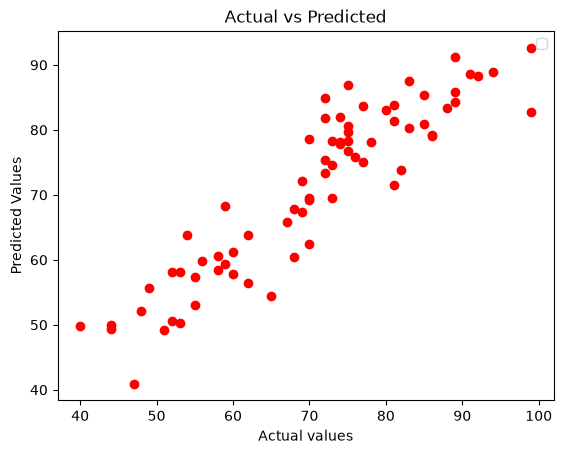

In [105]:
import matplotlib.pyplot as plt
plt.scatter(Y_test,y_pred,color='red')
plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Actual values")
plt.ylabel("Predicted Values")
plt.show()


In [119]:
import matplotlib.pyplot as plt
plt.scatter(df['sleep_hours'],df['test_scores'],color='red')
plt.grid()
plt.title("Actual vs Predicted")
plt.xlabel("Actual values")
plt.ylabel("Predicted Values")
plt.show()

KeyError: 'test_scores'